#Desafio 1

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [34]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/notas.csv')
df.head()

,livros,aulas,notas
0,0,9,45
1,1,15,57
2,0,10,45
3,2,16,51
4,4,10,65


In [35]:
X = df[['livros', 'aulas']]
y = df['notas']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)

print("=== Linear Regression ===")
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

=== Linear Regression ===
MSE: 184.3840884446345
MAE: 11.100391930095093
R2: -0.6762189858603136


In [38]:
model_mlp = Sequential([
    Dense(64, activation='relu', input_shape=(2,)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model_mlp.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model_mlp.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.1,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
y_pred_mlp = model_mlp.predict(X_test)

print("\n=== MLP ===")
print("MSE:", mean_squared_error(y_test, y_pred_mlp))
print("MAE:", mean_absolute_error(y_test, y_pred_mlp))
print("R2:", r2_score(y_test, y_pred_mlp))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step

=== MLP ===
MSE: 176.99623107910156
MAE: 10.92876148223877
R2: -0.6090565919876099


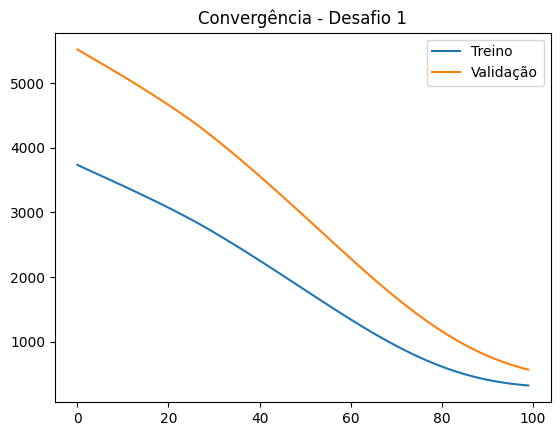

In [40]:
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.legend()
plt.title("Convergência - Desafio 1")
plt.show()

In [41]:
novos = np.array([
    [2, 10],
    [5, 20],
    [1, 5],
    [8, 25],
    [3, 15]
])

print("Linear:", model_lr.predict(novos))
print("MLP:", model_mlp.predict(novos))

Linear: [ 61.14614472  88.6371203   50.20979814 110.8100317   72.08249131]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
MLP: [[ 41.512325]
 [ 83.56521 ]
 [ 21.757717]
 [108.38922 ]
 [ 61.266933]]


# Desafio 2

In [42]:
diamonds = sns.load_dataset('diamonds')
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [43]:
diamonds = pd.get_dummies(diamonds, drop_first=True)

X = diamonds.drop('price', axis=1)
y = diamonds['price']

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)

print("=== Linear Regression (Diamonds) ===")
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

=== Linear Regression (Diamonds) ===
MSE: 1288705.4778516742
MAE: 737.1513665933275
R2: 0.9189331350419387


In [60]:
model_mlp = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

model_mlp.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model_mlp.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.2487 - mae: 0.4054 - val_loss: 0.1288 - val_mae: 0.3132
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1656 - mae: 0.3348 - val_loss: 0.0875 - val_mae: 0.2158
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1427 - mae: 0.2915 - val_loss: 0.0895 - val_mae: 0.2400
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1383 - mae: 0.2930 - val_loss: 0.0815 - val_mae: 0.2041
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1358 - mae: 0.2804 - val_loss: 0.0844 - val_mae: 0.2230
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1342 - mae: 0.2872 - val_loss: 0.0818 - val_mae: 0.2131
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1336 - mae: 0.2764 - val_loss: 0.0834 - val_mae: 0.2209
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1341 - mae: 0.2835 - val_loss: 0.0794 - val_mae: 0.1924
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1316 - 

In [47]:
y_pred_mlp = model_mlp.predict(X_test)

print("\n=== MLP (Diamonds) ===")
print("MSE:", mean_squared_error(y_test, y_pred_mlp))
print("MAE:", mean_absolute_error(y_test, y_pred_mlp))
print("R2:", r2_score(y_test, y_pred_mlp))

338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

=== MLP (Diamonds) ===
MSE: 373606.84375
MAE: 319.0666198730469
R2: 0.976498007774353


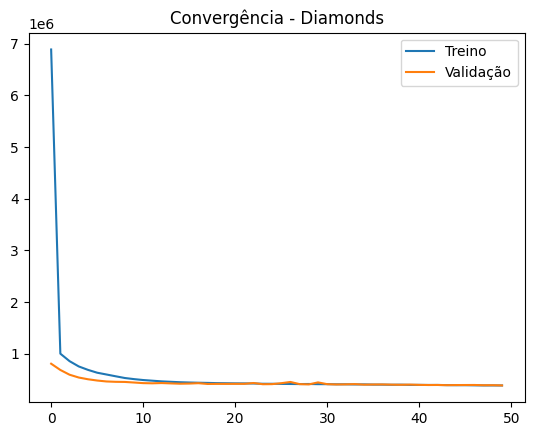

In [48]:
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.legend()
plt.title("Convergência - Diamonds")
plt.show()

In [49]:
print("Exemplo previsão:", model_lr.predict(X_test[:5]))

Exemplo previsão: [ 711.88577262 3191.72583727 1947.2464112  2077.29062598 9878.99820896]


# Desafio 3

In [50]:
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [51]:
titanic = titanic[['survived', 'pclass', 'sex', 'age', 'fare']]

titanic['age'].fillna(titanic['age'].mean(), inplace=True)

titanic = pd.get_dummies(titanic, drop_first=True)

/tmp/ipykernel_1205/79094163.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['age'].fillna(titanic['age'].mean(), inplace=True)


In [52]:
X = titanic.drop('survived', axis=1)
y = titanic['survived']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [54]:
model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_train, y_train)

y_pred = model_log.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

=== Logistic Regression ===
Accuracy: 0.7988826815642458
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [59]:
model_mlp = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_mlp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model_mlp.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.6531 - loss: 0.6699 - val_accuracy: 0.7500 - val_loss: 0.6152
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7266 - loss: 0.6035 - val_accuracy: 0.8194 - val_loss: 0.5351
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7422 - loss: 0.5530 - val_accuracy: 0.8194 - val_loss: 0.4671
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7500 - loss: 0.5128 - val_accuracy: 0.8750 - val_loss: 0.4165
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7750 - loss: 0.4891 - val_accuracy: 0.8889 - val_loss: 0.3702
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7766 - loss: 0.4703 - val_accuracy: 0.8889 - val_loss: 0.3445
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7781 - loss: 0.4585 - val_accuracy: 0.8889 - val_loss: 0.3291
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7859 - loss: 0.4525 - val_accuracy: 0.8889 - val_loss: 0.

In [56]:
y_pred_mlp = (model_mlp.predict(X_test) > 0.5).astype(int)

print("\n=== MLP ===")
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step

=== MLP ===
Accuracy: 0.8212290502793296
              precision    recall  f1-score   support

           0       0.81      0.90      0.86       105
           1       0.84      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



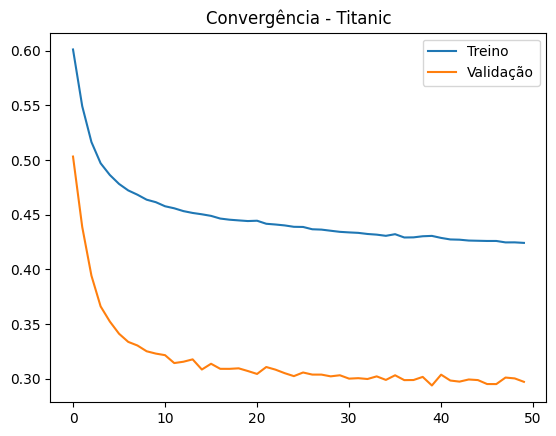

In [57]:
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.legend()
plt.title("Convergência - Titanic")
plt.show()

In [58]:
print("Exemplo previsão:", model_log.predict(X_test[:5]))

Exemplo previsão: [0 0 0 1 1]
